# Comparación de los algoritmos

Este notebook importa los algoritmos `FindFixedPoint.py`, `recorrido.py` que retornan true si dentro de la secuencia `A `existe un `A[i]=i`


In [1]:
import os, sys, math
from time import perf_counter
import numpy as np
import matplotlib.pyplot as plt
import importlib

# importa los .py con los algoritmos

import FindFixedPoint as ffp
import recorrido as rec

importlib.reload(ffp)
importlib.reload(rec)

find_fixed_point = ffp.find_fixed_point
recorrido = rec.recorrido


## 1) Pruebas de correctitud

El objetivo de estas pruebas es evaluar si los algoritmos están programados correctamente, de manera que evalua si la salida de la función es la que se espera con las siguientes entradas de prueba, las cuales también se  usan en el documento para justificar la metodología usada para resolver el problema.

### Casos del Recorrido
- `S_false = <2,3,5,7,8>`  → False  
- `S_true  = <1,2,4,4,6,8>` → True (A[4] = 4)

### Casos del FindFixedPoint
- `A1 = <-3,-1,0,3,5,7>` → True (A[3]=3)
- `A2 = <-10,-5,-2,0,1,4>` → False
- `A3 = <-10,-5,-2,0,4,8>` → True (A[4]=4)


In [5]:
# Casos para recorrido
S_false = [2, 3, 5, 7, 8]
S_true  = [1, 2, 4, 4, 6, 8]
# Como el documento está para pruenas para indices desde 1 hasta |A|, pero aquí vamos desde 0
S_false_0 = [x - 1 for x in S_false]
S_true_0  = [x - 1 for x in S_true]

# hace los tests
assert recorrido(S_false_0) is False
assert recorrido(S_true_0)  is True
print("OK: Recorrido ✅")

# Casos para FindFixedPoint
A1 = [-3, -1, 0, 3, 5, 7]
A2 = [-10, -5, -2, 0, 1, 4]
A3 = [-10, -5, -2, 0, 4, 8]

assert find_fixed_point(A1) is True
assert find_fixed_point(A2) is False
assert find_fixed_point(A3) is True
print("OK: FindFixedPoint ✅")


OK: Recorrido ✅
OK: FindFixedPoint ✅


## 2) Medición de tiempos


In [8]:
def tiempo_por_llamado (func, A, repeat=7, number=1):
    best = float("inf")
    for _ in range(repeat):
        t0 = perf_counter()
        for _ in range(number):
            func(A)
        t1 = perf_counter()
        best = min(best, (t1 - t0) / number)
    return best


## 4) Recolección de datos


In [9]:
def make_no_fixed_point_A0(n):
    # A0[i] = i+1 => no hay i con A0[i] == i (0-index) y el arreglo está ordenado
    return list(range(1, n + 1))

def run_benchmarks(ns, repeat=7, target_ops=2_000_000, max_number=200_000):
    out = []
    for n in ns:
        A0 = make_no_fixed_point_A0(n)

        number_lin = max(1, min(max_number, int(target_ops / max(1, n))))
        lg = max(1.0, math.log2(max(2, n)))
        number_log = max(1, min(max_number, int(target_ops / lg)))

        # Ambos algoritmos se evalúan sobre el mismo arreglo A0.
        t_rec = tiempo_por_llamado(recorrido,        A0, repeat=repeat, number=number_lin)
        t_bin = tiempo_por_llamado(find_fixed_point, A0, repeat=repeat, number=number_log)

        out.append((n, t_rec, t_bin))
    return out

ns = [2**k for k in range(8, 18)]  # 256 .. 131072
data = run_benchmarks(ns)

n_vals = np.array([d[0] for d in data], dtype=float)
t_rec  = np.array([d[1] for d in data], dtype=float)
t_bin  = np.array([d[2] for d in data], dtype=float)

print("Primeras filas:", data[:3])


Primeras filas: [(256, 2.564480542797596e-06, 4.439380299982076e-07), (512, 6.322995135716284e-06, 5.283083400013311e-07), (1024, 1.4611452636895292e-05, 6.151354200005698e-07)]


## 5) Gráfica: tiempo vs n


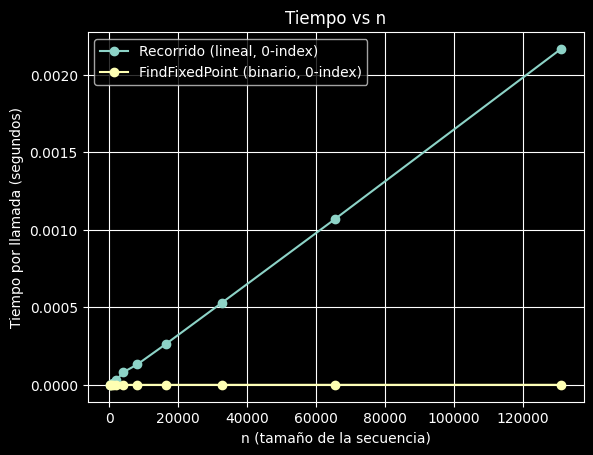

In [18]:
plt.figure()
plt.plot(n_vals, t_rec, marker="o", linestyle="-", label="Recorrido (lineal, 0-index)")
plt.plot(n_vals, t_bin, marker="o", linestyle="-", label="FindFixedPoint (binario, 0-index)")
plt.xlabel("n (tamaño de la secuencia)")
plt.ylabel("Tiempo por llamada (segundos)")
plt.title("Tiempo vs n")
plt.legend()
plt.grid(True)
plt.show()


## 6) Ajustes para evidenciar complejidad


In [16]:
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")

# Lineal: t ≈ a n + b
a, b = np.polyfit(n_vals, t_rec, deg=1)
t_rec_pred = a*n_vals + b
r2_rec = r2_score(t_rec, t_rec_pred)
print(f"Recorrido: t(n) ≈ {a:.3e}·n + {b:.3e}   | R^2 = {r2_rec:.4f}")

# Log: t ≈ c log2(n) + d
logn = np.log2(n_vals)
c, d = np.polyfit(logn, t_bin, deg=1)
t_bin_pred = c*logn + d
r2_bin = r2_score(t_bin, t_bin_pred)
print(f"FindFixedPoint: t(n) ≈ {c:.3e}·log2(n) + {d:.3e}   | R^2 = {r2_bin:.4f}")


Recorrido: t(n) ≈ 1.650e-08·n + -1.853e-06   | R^2 = 0.9999
FindFixedPoint: t(n) ≈ 7.941e-08·log2(n) + -1.776e-07   | R^2 = 0.9960


### Gráficas con los ajustes


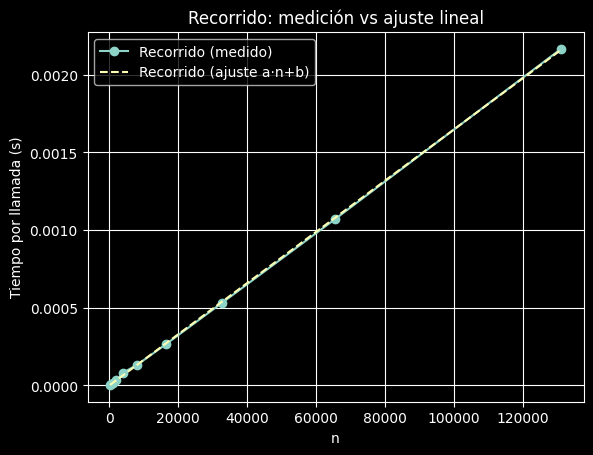

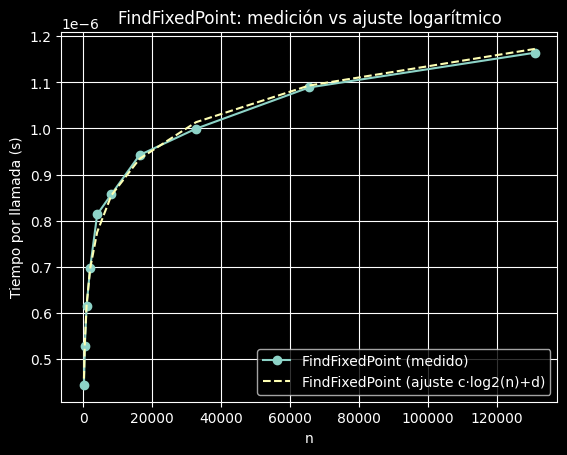

In [17]:
plt.figure()
plt.plot(n_vals, t_rec, marker="o", linestyle="-", label="Recorrido (medido)")
plt.plot(n_vals, t_rec_pred, linestyle="--", label="Recorrido (ajuste a·n+b)")
plt.xlabel("n")
plt.ylabel("Tiempo por llamada (s)")
plt.title("Recorrido: medición vs ajuste lineal")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(n_vals, t_bin, marker="o", linestyle="-", label="FindFixedPoint (medido)")
plt.plot(n_vals, t_bin_pred, linestyle="--", label="FindFixedPoint (ajuste c·log2(n)+d)")
plt.xlabel("n")
plt.ylabel("Tiempo por llamada (s)")
plt.title("FindFixedPoint: medición vs ajuste logarítmico")
plt.legend()
plt.grid(True)
plt.show()


In [14]:
for n in ns:
    A = make_no_fixed_point_A0(n)
    np.save(f"entradasA{n}.npy", np.array(A))